<a href="https://colab.research.google.com/github/Cheetah-lhp/MachineLearning/blob/main/NMHM_Linear_and_Ridge_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
diabetes = datasets.load_diabetes()
print("so chieu du lieu", diabetes.data.shape)
print("kieu du lieu", diabetes.data)
print("so chieu du lieu target", diabetes.target.shape)
print("kieu du lieu", diabetes.target)

print("5 mau du lieu dau tien")
print("input:", diabetes.data[:5])
print("target:", diabetes.target[:5])



so chieu du lieu (442, 10)
kieu du lieu [[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]
so chieu du lieu target (442,)
kieu du lieu [151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210

In [21]:
X_train = diabetes.data[:361]
y_train = diabetes.target[:361]
X_test = diabetes.data[361:]
y_test = diabetes.target[361:]


In [26]:
#model linear, neu muon chay ridge thi k chay block nay
model = linear_model.LinearRegression()
model.fit(X_train, y_train)
print("He so model [w1, ..., wn]: " , model.coef_)
print("bias w0: ", model.intercept_)
y_pred = model.predict(X_test)
result = pd.DataFrame({'Ground Truth: ': y_test, 'Prediction: ': y_pred})
result


He so model [w1, ..., wn]:  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
bias w0:  152.56041961097782


,Ground Truth:,Prediction:
0,182.0,121.621510
1,321.0,234.359479
2,58.0,163.999748
3,262.0,163.520115
4,206.0,167.189446
...,...,...
76,178.0,191.710701
77,104.0,104.626354
78,132.0,122.693494
79,220.0,210.454911


In [25]:
#model ridge
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]
for i in _lambda:
  model = linear_model.Ridge(alpha=i)
  model.fit(X_train, y_train)
  print("He so model [w1, ..., wn]: " , model.coef_)
  print("bias w0: ", model.intercept_)
mean_squared_error(y_test, y_pred)

He so model [w1, ..., wn]:  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
bias w0:  152.56041961097782
He so model [w1, ..., wn]:  [ 5.68731616e-02 -2.49742362e+02  5.18892642e+02  2.97154088e+02
 -6.31023676e+02  3.49304717e+02  2.39001187e+01  1.45917483e+02
  6.87163169e+02  1.05768660e+02]
bias w0:  152.56157120577737
He so model [w1, ..., wn]:  [   3.22793612 -245.94329459  519.225073    293.39148548 -279.46844843
   68.38523974 -128.15654952  108.60425222  550.58197759  108.84493941]
bias w0:  152.60305508638896
He so model [w1, ..., wn]:  [   6.43849599 -235.07303696  505.62597125  286.78915926 -120.25221674
  -54.00864554 -186.27195407  104.32422137  474.38252208  114.07146115]
bias w0:  152.6036714172744
He so model [w1, ..., wn]:  [   7.21214032 -231.59393464  500.69946998  284.78144978 -103.81254847
  -64.83890837 -190.20753132  105.88500196  463.27221767  11

2668.503529922832

In [23]:
r2_score(y_test, y_pred)

0.5564459687060811

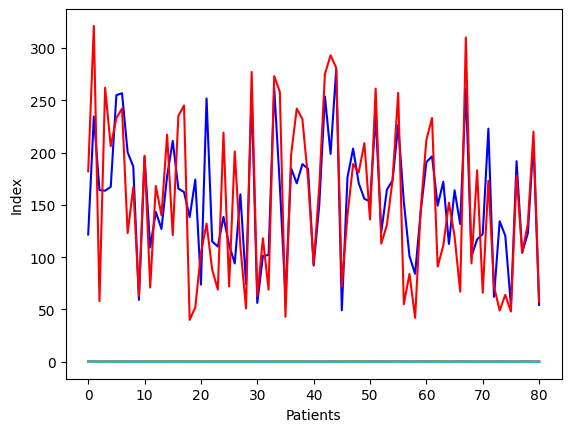

<Figure size 1200x800 with 0 Axes>

In [19]:
plt.plot(X_test)
plt.plot(y_pred, color='blue')
plt.plot(y_test, color='red')
plt.xlabel('Patients')
plt.ylabel('Index')
plt.figure(figsize=(12,8))
plt.show()